In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Load the dataset
df = pd.read_csv("train.csv")

# Display the first five rows
df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Caucasian,race_AfricanAmerican,...,citoglipton_No,insulin_No,glyburide-metformin_No,glipizide-metformin_No,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-pioglitazone_No,change_No,diabetesMed_Yes,readmitted
0,14,41,0,11,0,0,0,6,True,False,...,True,True,True,True,True,True,True,True,True,0
1,2,30,0,12,0,0,1,9,True,False,...,True,False,True,True,True,True,True,False,True,1
2,5,66,0,22,1,0,2,9,True,False,...,True,True,True,True,True,True,True,True,True,1
3,3,63,0,8,0,0,0,8,True,False,...,True,True,True,True,True,True,True,True,True,1
4,5,40,0,6,0,0,1,9,True,False,...,True,True,True,True,True,True,True,True,False,0


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (25000, 65)

Column names:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race_Caucasian', 'race_AfricanAmerican', 'gender_Female', 'age_[70-80)', 'age_[60-70)', 'age_[50-60)', 'age_[80-90)', 'age_[40-50)', 'payer_code_?', 'payer_code_MC', 'payer_code_HM', 'payer_code_SP', 'payer_code_BC', 'medical_specialty_?', 'medical_specialty_InternalMedicine', 'medical_specialty_Emergency/Trauma', 'medical_specialty_Family/GeneralPractice', 'medical_specialty_Cardiology', 'diag_1_428', 'diag_1_414', 'diag_1_786', 'diag_2_276', 'diag_2_428', 'diag_2_250', 'diag_2_427', 'diag_3_250', 'diag_3_401', 'diag_3_276', 'diag_3_428', 'max_glu_serum_None', 'A1Cresult_None', 'metformin_No', 'repaglinide_No', 'nateglinide_No', 'chlorpropamide_No', 'glimepiride_No', 'acetohexamide_No', 'glipizide_No', 'glyburide_No', 'tolbutamide_No', 'pioglitazone_No', 'rosiglitazone_No', 'acarbose_

In [4]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


readmitted
0    13590
1    11410
Name: count, dtype: int64


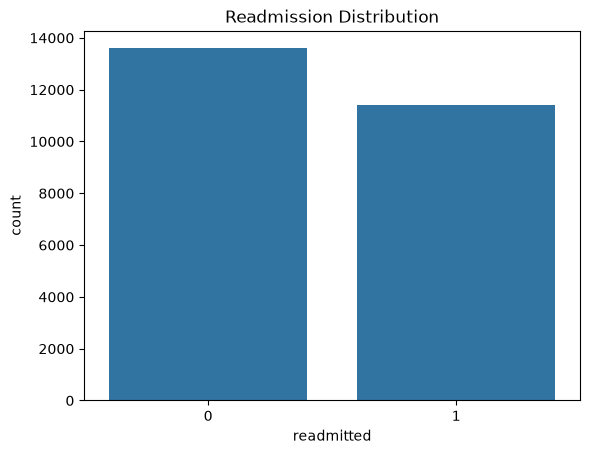

In [6]:
print(df["readmitted"].value_counts())

sns.countplot(data=df, x="readmitted")
plt.title("Readmission Distribution")
plt.show()

In [7]:
# Check columns with only one unique value
constant_columns = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:", constant_columns)

Constant columns: ['acetohexamide_No', 'examide_No', 'citoglipton_No', 'metformin-rosiglitazone_No', 'metformin-pioglitazone_No']


In [8]:
# Remove columns with only one unique value
df = df.drop(columns=constant_columns)

print("Removed columns:", constant_columns)
print("New dataset shape:", df.shape)

Removed columns: ['acetohexamide_No', 'examide_No', 'citoglipton_No', 'metformin-rosiglitazone_No', 'metformin-pioglitazone_No']
New dataset shape: (25000, 60)


In [9]:
# Confirm that no constant columns remain
constant_columns_after = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Remaining constant columns:", constant_columns_after)

Remaining constant columns: []


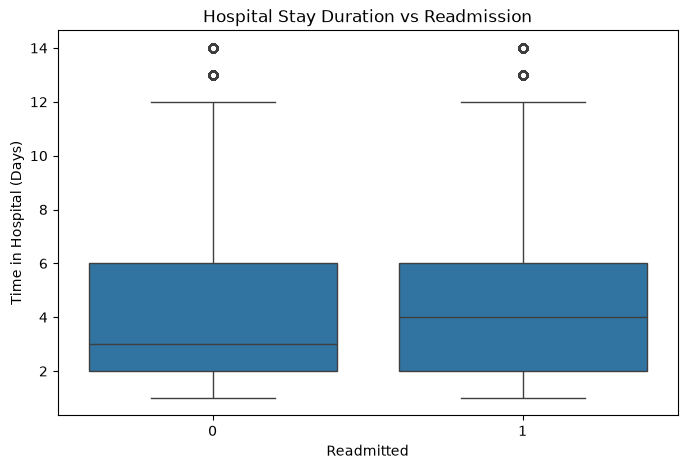

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital"
)

plt.title("Hospital Stay Duration vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Time in Hospital (Days)")
plt.show()

In [11]:
numerical_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Compare average values for readmitted and non-readmitted patients
df.groupby("readmitted")[numerical_cols].mean().T

readmitted,0,1
time_in_hospital,4.237822,4.583611
num_lab_procedures,42.233996,43.824978
num_procedures,1.419132,1.248116
num_medications,15.569610,16.487292
number_outpatient,0.268212,0.482296
number_emergency,0.112656,0.311218
number_inpatient,0.392494,0.941367
number_diagnoses,7.200662,7.681595


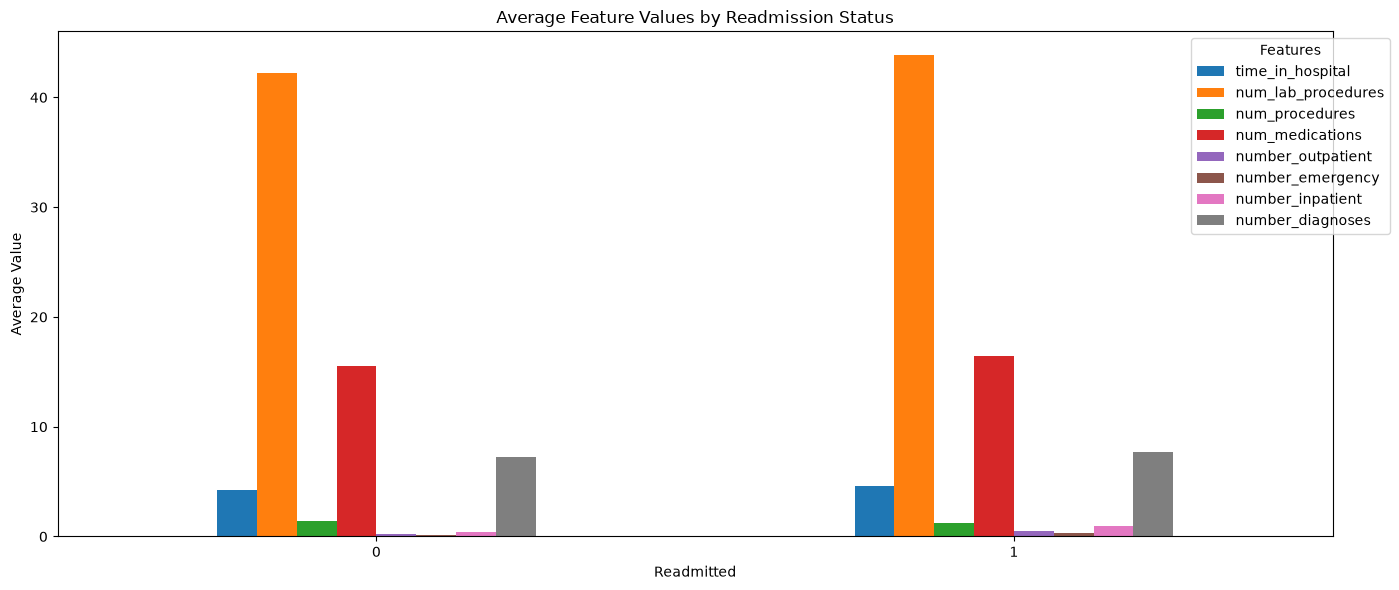

In [12]:
df.groupby("readmitted")[numerical_cols].mean().plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Average Feature Values by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [13]:
# Calculate correlations with the target
correlations = (
    df[numerical_cols + ["readmitted"]]
    .corr()["readmitted"]
    .drop("readmitted")
    .sort_values(ascending=False)
)

print(correlations)

number_inpatient      0.216490
number_diagnoses      0.123423
number_emergency      0.100618
number_outpatient     0.087092
time_in_hospital      0.057583
num_medications       0.056378
num_lab_procedures    0.040087
num_procedures       -0.049950
Name: readmitted, dtype: float64


In [14]:
# Calculate readmission rate for each number of previous inpatient visits
readmission_by_inpatient = (
    df.groupby("number_inpatient")["readmitted"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "readmission_rate"})
)

# Convert the rate into a percentage
readmission_by_inpatient["readmission_rate"] *= 100

readmission_by_inpatient

,count,readmission_rate
number_inpatient,,
0,16542,37.909564
1,4792,54.465776
2,1889,65.272631
3,871,67.853042
4,412,73.058252
5,198,79.797980
6,111,81.981982
7,75,77.333333
8,38,86.842105


In [15]:
# Group higher inpatient visit counts together
df["inpatient_group"] = df["number_inpatient"].apply(
    lambda x: "3+" if x >= 3 else str(x)
)

# Calculate readmission rates
grouped_readmission = (
    df.groupby("inpatient_group", observed=True)["readmitted"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "readmission_rate"})
)

grouped_readmission["readmission_rate"] *= 100

# Display groups in a meaningful order
group_order = ["0", "1", "2", "3+"]

grouped_readmission.reindex(group_order)


,count,readmission_rate
inpatient_group,,
0,16542,37.909564
1,4792,54.465776
2,1889,65.272631
3+,1777,72.931908


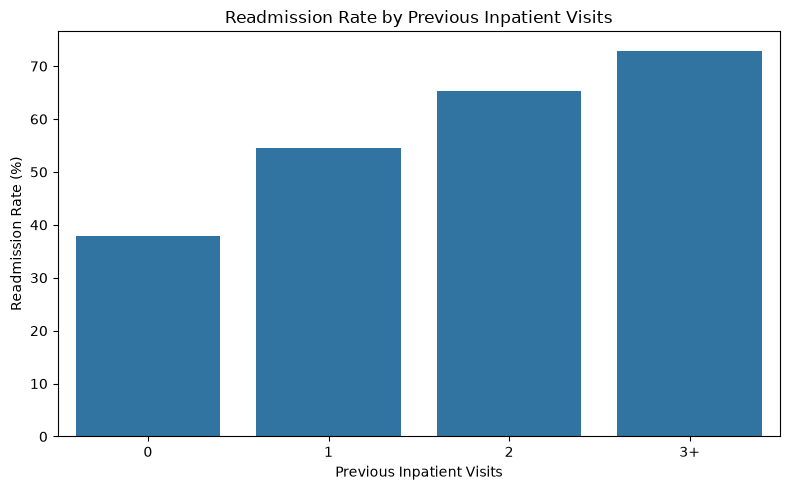

In [16]:
plot_data = grouped_readmission.reindex(group_order).reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_data,
    x="inpatient_group",
    y="readmission_rate"
)

plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [17]:
# Calculate readmission rates by age group
age_columns = [
    "age_[40-50)",
    "age_[50-60)",
    "age_[60-70)",
    "age_[70-80)",
    "age_[80-90)"
]

age_readmission = {}

for col in age_columns:
    age_readmission[col] = df.loc[df[col] == True, "readmitted"].mean() * 100

age_readmission = pd.Series(age_readmission)

print(age_readmission)

age_[40-50)    44.810544
age_[50-60)    43.310185
age_[60-70)    46.273576
age_[70-80)    47.206748
age_[80-90)    47.968053
dtype: float64


In [18]:
# Group emergency visits for easier interpretation
df["emergency_group"] = df["number_emergency"].apply(
    lambda x: "2+" if x >= 2 else str(x)
)

emergency_readmission = (
    df.groupby("emergency_group", observed=True)["readmitted"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "readmission_rate"})
)

emergency_readmission["readmission_rate"] *= 100

emergency_readmission

,count,readmission_rate
emergency_group,,
0,22143,43.336495
1,1904,59.558824
2+,953,71.353620


In [19]:
# Create medication groups
df["medication_group"] = pd.cut(
    df["num_medications"],
    bins=[-1, 10, 20, 30, float("inf")],
    labels=["0-10", "11-20", "21-30", "31+"]
)

# Calculate readmission rates
medication_readmission = (
    df.groupby("medication_group", observed=True)["readmitted"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "readmission_rate"})
)

medication_readmission["readmission_rate"] *= 100

medication_readmission

,count,readmission_rate
medication_group,,
0-10,6402,38.159950
11-20,12774,47.792391
21-30,4555,50.911087
31+,1269,42.789598


In [20]:
# Group the number of diagnoses
df["diagnosis_group"] = pd.cut(
    df["number_diagnoses"],
    bins=[0, 3, 6, 9, 16],
    labels=["1-3", "4-6", "7-9", "10+"]
)

# Calculate readmission rates
diagnosis_readmission = (
    df.groupby("diagnosis_group", observed=True)["readmitted"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "readmission_rate"})
)

diagnosis_readmission["readmission_rate"] *= 100

diagnosis_readmission

,count,readmission_rate
diagnosis_group,,
1-3,1024,32.324219
4-6,6629,37.713079
7-9,17317,49.448519
10+,30,53.333333


In [21]:
# Select numerical features
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000000,0.324888,0.192580,0.461874,-0.013918,-0.013573,0.073334,0.215924
num_lab_procedures,0.324888,1.000000,0.057895,0.273101,-0.018161,-0.016669,0.038290,0.154354
num_procedures,0.192580,0.057895,1.000000,0.390198,-0.028145,-0.039572,-0.073735,0.071921
num_medications,0.461874,0.273101,0.390198,1.000000,0.039319,0.011724,0.058422,0.267158
number_outpatient,-0.013918,-0.018161,-0.028145,0.039319,1.000000,0.095898,0.115013,0.096235
number_emergency,-0.013573,-0.016669,-0.039572,0.011724,0.095898,1.000000,0.250454,0.054801
number_inpatient,0.073334,0.038290,-0.073735,0.058422,0.115013,0.250454,1.000000,0.109749
number_diagnoses,0.215924,0.154354,0.071921,0.267158,0.096235,0.054801,0.109749,1.000000


In [22]:
# Remove columns created only for EDA
eda_columns = [
    "inpatient_group",
    "emergency_group",
    "medication_group",
    "diagnosis_group"
]

df = df.drop(columns=eda_columns, errors="ignore")

df.shape

(25000, 60)

In [24]:
# Separate input features and target
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (25000, 59)
Target shape: (25000,)


In [25]:
# Convert Boolean columns to integers
bool_cols = X.select_dtypes(include="bool").columns

X[bool_cols] = X[bool_cols].astype(int)

X.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Caucasian,race_AfricanAmerican,...,acarbose_No,miglitol_No,troglitazone_No,tolazamide_No,insulin_No,glyburide-metformin_No,glipizide-metformin_No,glimepiride-pioglitazone_No,change_No,diabetesMed_Yes
0,14,41,0,11,0,0,0,6,1,0,...,1,1,1,1,1,1,1,1,1,1
1,2,30,0,12,0,0,1,9,1,0,...,1,1,1,1,0,1,1,1,0,1
2,5,66,0,22,1,0,2,9,1,0,...,1,1,1,1,1,1,1,1,1,1
3,3,63,0,8,0,0,0,8,1,0,...,1,1,1,1,1,1,1,1,1,1
4,5,40,0,6,0,0,1,9,1,0,...,1,1,1,1,1,1,1,1,1,0


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20000, 59)
X_test: (5000, 59)
y_train: (20000,)
y_test: (5000,)


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [29]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](59,)","['time_in_hospital','num_lab_procedures','num_procedures',..., 'glimepiride-pioglitazone_No','change_No','diabetesMed_Yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,59
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [30]:
y_pred = logistic_model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [31]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.6174
Precision: 0.6206671026814912
Recall   : 0.41586327782646804
F1-score : 0.49803201259511937


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2138  580]
 [1333  949]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [36]:
rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2718
           1       0.59      0.50      0.54      2282

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.60      5000
weighted avg       0.61      0.61      0.61      5000



In [37]:
# Get the importance of every feature
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
1,num_lab_procedures,0.119224
3,num_medications,0.106968
0,time_in_hospital,0.078559
6,number_inpatient,0.058639
7,number_diagnoses,0.052375
2,num_procedures,0.052247
10,gender_Female,0.024448
4,number_outpatient,0.023622
5,number_emergency,0.019657
21,medical_specialty_?,0.019425


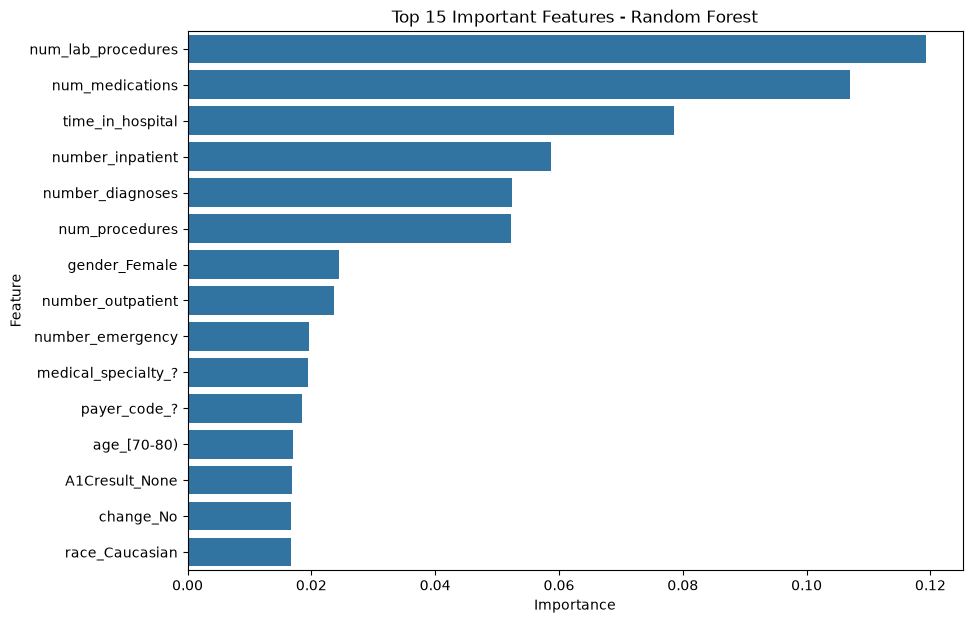

In [38]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model

In [40]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation F1-score: 0.581899673251295


In [41]:
best_rf = grid_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)

print(classification_report(y_test, tuned_rf_pred))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      2718
           1       0.58      0.57      0.58      2282

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.62      0.62      0.62      5000



In [42]:
from sklearn.metrics import confusion_matrix

tuned_cm = confusion_matrix(y_test, tuned_rf_pred)

print(tuned_cm)

[[1780  938]
 [ 978 1304]]


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, tuned_rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, tuned_rf_pred)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, tuned_rf_pred)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6174,0.620667,0.415863,0.498032
1,Random Forest,0.6146,0.592496,0.498247,0.541300
2,Tuned Random Forest,0.6168,0.581624,0.571429,0.576481


In [44]:
# Get the probability of readmission
y_prob = best_rf.predict_proba(X_test)[:, 1]

y_prob[:10]

array([0.30745015, 0.5778674 , 0.49050915, 0.2983907 , 0.57721729,
       0.48496807, 0.50073213, 0.52008704, 0.68281329, 0.51038625])

In [45]:
from sklearn.metrics import classification_report

# Use 0.4 instead of the default 0.5 threshold
threshold = 0.4

threshold_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, threshold_pred))

              precision    recall  f1-score   support

           0       0.71      0.34      0.46      2718
           1       0.51      0.84      0.64      2282

    accuracy                           0.57      5000
   macro avg       0.61      0.59      0.55      5000
weighted avg       0.62      0.57      0.54      5000



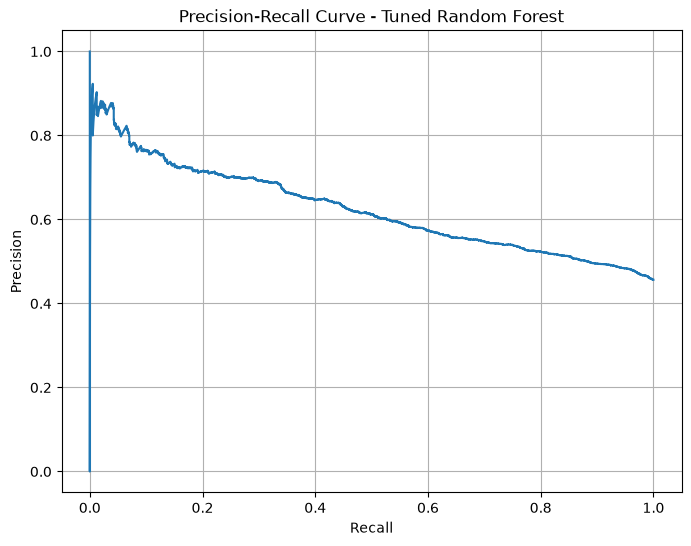

In [46]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall at different thresholds
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Plot the curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.grid()
plt.show()

In [47]:
from sklearn.metrics import f1_score
import numpy as np

thresholds_to_test = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1_score
0,0.10,0.456400,1.000000,0.626751
1,0.15,0.456422,0.998247,0.626427
2,0.20,0.458669,0.996933,0.628279
3,0.25,0.465006,0.989921,0.632773
4,0.30,0.475996,0.968887,0.638372
5,0.35,0.492716,0.918931,0.641481
6,0.40,0.514694,0.836547,0.637289
7,0.45,0.543624,0.709904,0.615735
8,0.50,0.581624,0.571429,0.576481
9,0.55,0.629426,0.451797,0.526020


In [48]:
best_threshold_row = threshold_results.loc[
    threshold_results["f1_score"].idxmax()
]

best_threshold_row

threshold    0.350000
precision    0.492716
recall       0.918931
f1_score     0.641481
Name: 5, dtype: float64

In [49]:
from sklearn.metrics import confusion_matrix

# Use the threshold that gave the highest tested F1-score
best_threshold = 0.35

best_threshold_pred = (y_prob >= best_threshold).astype(int)

# Generate the confusion matrix
best_threshold_cm = confusion_matrix(y_test, best_threshold_pred)

print(best_threshold_cm)

[[ 559 2159]
 [ 185 2097]]


In [50]:
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate ROC-AUC using predicted probabilities
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.663986124251025


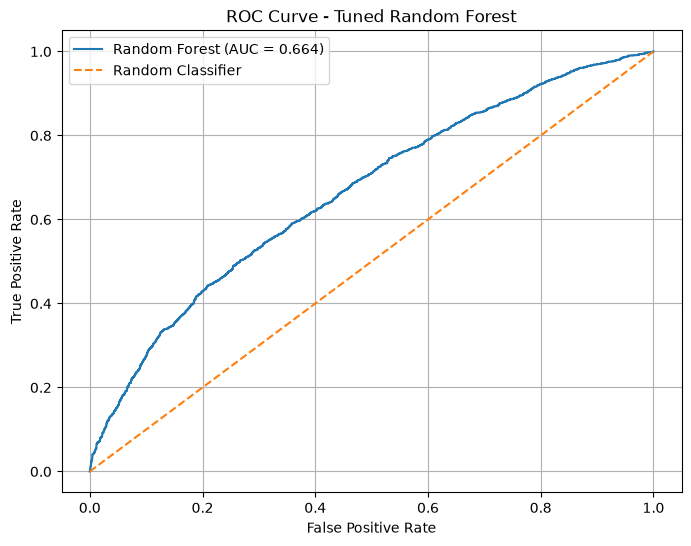

In [51]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid()
plt.show()

In [52]:
# Predictions on training data
train_pred = best_rf.predict(X_train)

# Predictions on testing data
test_pred = best_rf.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Training probabilities
train_prob = best_rf.predict_proba(X_train)[:, 1]

# Testing probabilities
test_prob = best_rf.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "ROC-AUC"],
    "Training": [
        accuracy_score(y_train, train_pred),
        f1_score(y_train, train_pred),
        roc_auc_score(y_train, train_prob)
    ],
    "Testing": [
        accuracy_score(y_test, test_pred),
        f1_score(y_test, test_pred),
        roc_auc_score(y_test, test_prob)
    ]
})

comparison

,Metric,Training,Testing
0,Accuracy,0.906950,0.616800
1,F1-score,0.898378,0.576481
2,ROC-AUC,0.973182,0.663986


model is clearly showing overfitting

In [54]:
from sklearn.ensemble import RandomForestClassifier

regularized_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

regularized_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [55]:
regularized_train_pred = regularized_rf.predict(X_train)
regularized_test_pred = regularized_rf.predict(X_test)

regularized_train_prob = regularized_rf.predict_proba(X_train)[:, 1]
regularized_test_prob = regularized_rf.predict_proba(X_test)[:, 1]

regularized_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "ROC-AUC"],
    "Training": [
        accuracy_score(y_train, regularized_train_pred),
        f1_score(y_train, regularized_train_pred),
        roc_auc_score(y_train, regularized_train_prob)
    ],
    "Testing": [
        accuracy_score(y_test, regularized_test_pred),
        f1_score(y_test, regularized_test_pred),
        roc_auc_score(y_test, regularized_test_prob)
    ]
})

regularized_comparison

,Metric,Training,Testing
0,Accuracy,0.672950,0.618000
1,F1-score,0.634070,0.573089
2,ROC-AUC,0.744482,0.662598


In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    regularized_rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("F1-score for each fold:", cv_scores)
print("Mean cross-validation F1-score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

F1-score for each fold: [0.57934936 0.57751612 0.57817273 0.57618364 0.5912266 ]
Mean cross-validation F1-score: 0.5804896914184112
Standard deviation: 0.005465053086160073


In [57]:
from sklearn.model_selection import train_test_split

X_inner_train, X_val, y_inner_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [58]:
validation_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

validation_rf.fit(X_inner_train, y_inner_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

val_prob = validation_rf.predict_proba(X_val)[:, 1]

thresholds_to_test = np.arange(0.1, 0.91, 0.05)

validation_results = []

for threshold in thresholds_to_test:
    val_pred = (val_prob >= threshold).astype(int)

    validation_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1_score": f1_score(y_val, val_pred)
    })

validation_results = pd.DataFrame(validation_results)

best_validation_threshold = validation_results.loc[
    validation_results["f1_score"].idxmax()
]

best_validation_threshold

c:\Users\gandl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gandl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


threshold    0.400000
precision    0.506169
recall       0.898686
f1_score     0.647593
Name: 6, dtype: float64

In [60]:
# Train the final model on all training data
final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [61]:
# Get readmission probabilities for the test set
final_test_prob = final_rf.predict_proba(X_test)[:, 1]

# Apply the threshold selected using validation data
final_threshold = 0.40

final_test_pred = (
    final_test_prob >= final_threshold
).astype(int)

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, final_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_test_pred))

              precision    recall  f1-score   support

           0       0.74      0.25      0.38      2718
           1       0.50      0.89      0.64      2282

    accuracy                           0.55      5000
   macro avg       0.62      0.57      0.51      5000
weighted avg       0.63      0.55      0.50      5000

Confusion Matrix:
[[ 687 2031]
 [ 244 2038]]


In [63]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
perm_importance = permutation_importance(
    validation_rf,
    X_val,
    y_val,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [65]:
importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
6,number_inpatient,0.059735
5,number_emergency,0.008897
7,number_diagnoses,0.008799
4,number_outpatient,0.005739
26,diag_1_428,0.004216
58,diabetesMed_Yes,0.003620
17,payer_code_MC,0.002476
30,diag_2_428,0.002418
8,race_Caucasian,0.002006
33,diag_3_250,0.001830


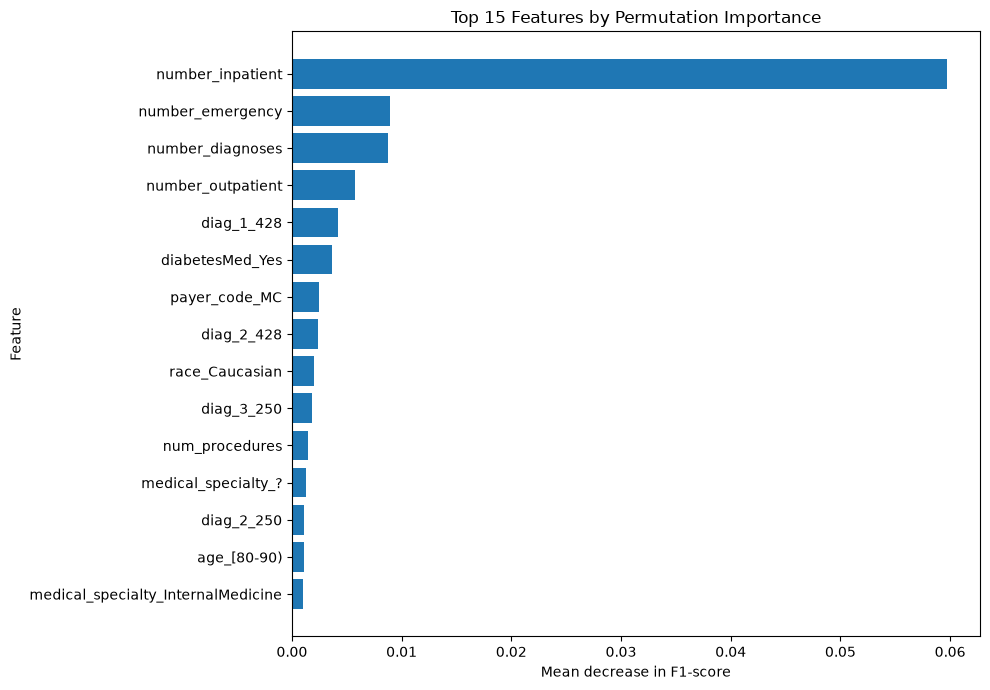

In [66]:
top_features = importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")
plt.tight_layout()
plt.show()

In [67]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

In [68]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [69]:
hgb_prob = hgb_model.predict_proba(X_test)[:, 1]

In [70]:
hgb_threshold = 0.40

hgb_pred = (hgb_prob >= hgb_threshold).astype(int)

print(classification_report(y_test, hgb_pred))

print("ROC-AUC:", roc_auc_score(y_test, hgb_prob))

              precision    recall  f1-score   support

           0       0.69      0.48      0.57      2718
           1       0.55      0.74      0.63      2282

    accuracy                           0.60      5000
   macro avg       0.62      0.61      0.60      5000
weighted avg       0.62      0.60      0.59      5000

ROC-AUC: 0.6652863308136945


In [71]:
comparison = pd.DataFrame({
    "Model": [
        "Regularized Random Forest",
        "HistGradientBoosting"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, final_test_prob),
        roc_auc_score(y_test, hgb_prob)
    ],
    "Readmission F1": [
        f1_score(y_test, final_test_pred),
        f1_score(y_test, hgb_pred)
    ]
})

comparison

,Model,ROC-AUC,Readmission F1
0,Regularized Random Forest,0.662598,0.641789
1,HistGradientBoosting,0.665286,0.627466


In [72]:
import joblib

final_rf = regularized_rf

joblib.dump(final_rf, "readmission_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [73]:
loaded_model = joblib.load("readmission_model.pkl")

loaded_predictions = loaded_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, loaded_predictions))

ROC-AUC: 0.662598130166082
